## 1) Libraries Installation
##### The cell below is to help you keep track the libraries used and install them quickly.
##### Ensure the correct library names are used, and follow the syntax: **%pip install PACKAGE_NAME**.

In [181]:
#%pip install pandas
#%pip install matplotlib
#%pip install tabulate

## 2) Main Section for Code
### **ALL code for machine learning and dataset analysis** should be entered below.
##### Ensure that your code is clear and readable.
##### Remember to include comments and markdown notes as necessary to explain and highlight important segments of your code.

In [182]:
# Import packages
import numpy as np
import pandas as pd
from statsmodels.tsa.ardl import ARDL
from statsmodels.tools.eval_measures import aic, bic
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from tabulate import tabulate
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime


In [183]:
# Read in the Quarterly and Monthly Data
df1 = pd.read_csv("Quarterly Data.csv")
df2 = pd.read_csv("Monthly Data.csv")

In [184]:
## Step 1: Filter out the selected columns
selected_columns_1 = ["sasdate",
    "GDPC1", "INDPRO", "UNRATE", "PPIACO", "CPIAUCSL", "FEDFUNDS", "HOUST",
    "AMDMNOx", "TB3MS", "TB6MS", "GS1", "GS10", "BAA", "AAA"
]

selected_columns_2 = ["sasdate", "INDPRO", "UNRATE", "CPIAUCSL", "FEDFUNDS", "HOUST",
    "AMDMNOx", "TB3MS", "TB6MS", "GS1", "GS10", "BAA", "AAA"
]

df1_filtered = df1[selected_columns_1]
df2_filtered = df2[selected_columns_2]

# Display the first few rows of the filtered DataFrame
print(df1_filtered.head())
print(df2_filtered.head())

     sasdate     GDPC1   INDPRO  UNRATE   PPIACO  CPIAUCSL  FEDFUNDS  \
0    factors     0.000   0.0000  0.0000   0.0000    0.0000    1.0000   
1  transform     5.000   5.0000  2.0000   6.0000    6.0000    2.0000   
2   3/1/1959  3352.129  22.3558  5.8333  31.7000   28.9933    2.5700   
3   6/1/1959  3427.667  23.4400  5.1000  31.7667   29.0433    3.0833   
4   9/1/1959  3430.057  22.4813  5.2667  31.6667   29.1933    3.5767   

       HOUST      AMDMNOx   TB3MS   TB6MS     GS1    GS10     BAA     AAA  
0     0.0000       1.0000  1.0000  0.0000  0.0000  0.0000  0.0000  0.0000  
1     5.0000       5.0000  2.0000  2.0000  2.0000  2.0000  2.0000  2.0000  
2  1648.0000   98532.9362  2.7733  3.1167  3.5033  3.9900  4.8700  4.1300  
3  1530.3333  100718.0204  3.0000  3.3733  3.9167  4.2567  4.9533  4.3533  
4  1505.6667   91750.9544  3.5400  4.1300  4.6033  4.5033  5.1167  4.4733  
      sasdate   INDPRO  UNRATE  CPIAUCSL  FEDFUNDS  HOUST      AMDMNOx  TB3MS  \
0  Transform:   5.0000     2.0

In [185]:
## Step 2: Stationarise the Variables
header_row1 = df1_filtered[0:1]
transform_row1 = df1_filtered.loc[1]
data1 = df1_filtered.loc[2:]

def transform_column(series, transform_type):
    if transform_type == 1:
        return series  
    elif transform_type == 2:
        return series.diff()  
    elif transform_type == 3:
        return series.diff().diff()  
    elif transform_type == 4:
        return np.log(series) 
    elif transform_type == 5:
        return np.log(series).diff()  
    elif transform_type == 6:
        return np.log(series).diff().diff() 
    elif transform_type == 7:
        return (series / series.shift(1) - 1).diff()
    else:
        return series

    
for col in data1.columns: 
    if header_row1.iloc[0][col] != 1:
        transform_type1 = transform_row1[col]
        data1[col] = transform_column(data1[col], transform_type1)

df1_stationarised = pd.concat([df1_filtered.iloc[0:2], data1])
df1_stationarised = df1_stationarised.drop(index = 2)
df1_stationarised = df1_stationarised.drop(index = [0,1])
df1_stationarised = df1_stationarised.dropna()

print(df1_stationarised.head())


     sasdate     GDPC1    INDPRO  UNRATE    PPIACO  CPIAUCSL  FEDFUNDS  \
4   9/1/1959  0.000697 -0.041760  0.1667 -0.005255  0.003428    3.5767   
5  12/1/1959  0.002846  0.004770  0.3333 -0.001069  0.000883    3.9900   
6   3/1/1960  0.022237  0.058548 -0.4667  0.008443 -0.005126    3.9333   
7   6/1/1960 -0.005398 -0.021938  0.1000 -0.002121  0.005081    3.6967   
8   9/1/1960  0.004887 -0.016581  0.3000 -0.005257 -0.005425    2.9367   

      HOUST     AMDMNOx   TB3MS   TB6MS     GS1    GS10     BAA     AAA  
4 -0.016250  91750.9544  3.5400  0.7567  0.6866  0.2466  0.1634  0.1200  
5 -0.032628  92327.9938  4.2300  0.5100  0.3134  0.0800  0.1566  0.0967  
6 -0.071086  91519.9682  3.8733 -0.4233 -0.3467 -0.0966  0.0367 -0.0167  
7 -0.067293  90727.1195  2.9933 -0.9267 -0.7000 -0.2267 -0.0633 -0.1000  
8 -0.045407  92132.5319  2.3600 -0.5800 -0.7967 -0.4267 -0.1434 -0.1400  


/var/folders/9s/g3dm127d28j72x1bc2hpx0980000gp/T/ipykernel_739/1186813339.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1[col] = transform_column(data1[col], transform_type1)


In [186]:
# Extract necessary rows
header_row2 = df2_filtered.iloc[0:1]  # Ensure correct row slicing
transform_row2 = df2_filtered.iloc[1]
data2 = df2_filtered.iloc[2:]

# Function to apply transformations
def transform_column(series, transform_type):
    try:
        if transform_type == 1:
            return series  
        elif transform_type == 2:
            return series.diff()  
        elif transform_type == 3:
            return series.diff().diff()  
        elif transform_type == 4:
            return np.log(series)  
        elif transform_type == 5:
            return np.log(series).diff()  
        elif transform_type == 6:
            return np.log(series).diff().diff()  
        elif transform_type == 7:
            return (series / series.shift(1) - 1).diff()
        else:
            return series
    except Exception as e:
        print(f"Error transforming column: {e}")
        return series  # Return original series if an error occurs

# Apply transformations
for col in data2.columns: 
    if header_row2.iloc[0][col] != 1:
        transform_type2 = transform_row2[col]
        data2[col] = transform_column(data2[col], transform_type2)

# Reconstruct the dataframe
df2_stationarised = pd.concat([df2_filtered.iloc[0:2], data2])

# Drop unnecessary rows
df2_stationarised = df2_stationarised.drop(index=[0, 1, 2])

# Handle NaN and Inf values
df2_stationarised.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace Inf with NaN
df2_stationarised.dropna(inplace=True)  # Drop all rows with NaN

# Display result
print(df2_stationarised.head())

    sasdate   INDPRO    UNRATE  CPIAUCSL  FEDFUNDS  HOUST      AMDMNOx  TB3MS  \
4  4/1/1959  23.1981 -0.021922     28.98      2.96   1590  15919.42165   2.95   
5  5/1/1959  23.5476  0.054690     29.04      2.90   1498  15248.82330   2.84   
6  6/1/1959  23.5744 -0.000385     29.11      3.39   1503  15961.74553   3.21   
7  7/1/1959  23.0099  0.039605     29.15      3.47   1547  14743.75835   3.20   
8  8/1/1959  22.2304 -0.000385     29.18      3.50   1430  14046.82514   3.38   

   TB6MS   GS1  GS10   BAA   AAA  
4   3.27  3.72  4.12  4.86  4.23  
5   3.33  3.96  4.31  4.96  4.37  
6   3.52  4.07  4.34  5.04  4.46  
7   3.82  4.39  4.40  5.08  4.47  
8   3.87  4.42  4.43  5.09  4.43  


/var/folders/9s/g3dm127d28j72x1bc2hpx0980000gp/T/ipykernel_739/3682717008.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2[col] = transform_column(data2[col], transform_type2)


In [187]:
# Step 3: Use BIC / AIC to find optimal number of lags for Y and X Variables

# For QUARTERLY DATA
# Set dependent and independent variables
y = df1_stationarised['GDPC1']
X = df1_stationarised.drop(columns=['GDPC1', 'sasdate'])  # Drop 'GDPC1' to use the rest as independent variables

# Initialize variables to store the best AIC and BIC
best_aic1 = float("inf")
best_bic1 = float("inf")
best_lag_aic1 = (0, 0)
best_lag_bic1 = (0, 0)

# Set range for testing lags (for example, lags from 1 to 5)
max_lag1 = 11

# Loop over different lag combinations for Y (GDPC1) and X
for p in range(1, max_lag1 + 1):  # Lag for Y (dependent variable)
    for q in range(1, max_lag1 + 1):  # Lag for X (independent variables)
        
        # Fit the ARDL model
        model_1 = ARDL(y, exog=X, lags=p, order=q)
        results1 = model_1.fit()
        
        # Calculate AIC and BIC
        model_aic1 = results1.aic
        model_bic1 = results1.bic
        
        # Check if the current model has the best AIC and BIC
        if model_aic1 < best_aic1:
            best_aic1 = model_aic1
            best_lag_aic1 = (p, q)
        
            best_bic1 = model_bic1
            best_lag_bic1 = (p, q)

# Output the results
print(f"Best AIC: {best_aic1} with p={best_lag_aic1[0]}, q={best_lag_aic1[1]}") # p is no of lags for GDP, q is no of lags for X variables
print(f"Best BIC: {best_bic1} with p={best_lag_bic1[0]}, q={best_lag_bic1[1]}")



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/

Best AIC: -1990.5327192526247 with p=1, q=11
Best BIC: -1424.384339921156 with p=1, q=11


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/

In [188]:
# For MONTHLY DATA (use INDPRO as Y-Variable)
df2_stationarised = df2_stationarised.apply(pd.to_numeric, errors='coerce')

# Set dependent and independent variables
y2 = df2_stationarised['INDPRO']
x2 = df2_stationarised.drop(columns=['INDPRO', 'sasdate'])  # Drop 'INDPRO' to use the rest as independent variables

# Initialize variables to store the best AIC and BIC
best_aic2 = float("inf")
best_bic2 = float("inf")
best_lag_aic2 = (0, 0)
best_lag_bic2 = (0, 0)

# Set range for testing lags (for example, lags from 1 to 5)
max_lag2 = 4

# Loop over different lag combinations for Y (INDPRO) and X
for r in range(1, max_lag2 + 1):  # Lag for Y (dependent variable)
    for s in range(1, max_lag2 + 1):  # Lag for X (independent variables)
        
        try:
        # Fit the ARDL model
            model_2 = ARDL(y2, exog=x2, lags=r, order=s)
            results2 = model_2.fit()
        
        # Calculate AIC and BIC
            model_aic2 = results2.aic
            model_bic2 = results2.bic
        
        # Check if the current model has the best AIC and BIC
            if model_aic2 < best_aic2:
                best_aic2 = model_aic2
                best_lag_aic2 = (r, s)
        
            if model_bic2 < best_bic2:
                best_bic2 = model_bic2
                best_lag_bic2 = (r, s)

        except Exception as e:
            print(f"Skipping r={r}, s={s} due to error: {e}")

# Output the results
print(f"Best AIC: {best_aic2} with r={best_lag_aic2[0]}, s={best_lag_aic2[1]}") # r is no of lags for INDPRO, s is no of lags for X variables
print(f"Best BIC: {best_bic2} with r={best_lag_bic2[0]}, s={best_lag_bic2[1]}")

Best AIC: 1120.601840337203 with r=4, s=3
Best BIC: 1323.8999522385539 with r=1, s=2


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/

In [189]:
# Step 4: Autoregressive Distributed Lag Model

df1_stationarised['sasdate'] = pd.to_datetime(df1_stationarised['sasdate'], errors='coerce')
df1_stationarised.set_index("sasdate", inplace = True)
train, test = df1_stationarised['GDPC1'][:-3], df1_stationarised['GDPC1'][-3:]
model = AutoReg(train, lags = 1) 
fitted_model = model.fit()
 
forecast = fitted_model.predict(start=len(train), end=len(train) + len(test) - 1)

errors = test - forecast 
rmsfe = np.sqrt(np.mean(errors**2))
print(rmsfe)

0.0019496134033128712


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [190]:
# Descriptive Statistics

#df1_stationarised.describe()
# Assuming df1_stationarised is your DataFrame
half_size = len(df1_stationarised) // 2

# Split into two halves
df1_part1 = df1_stationarised.iloc[:half_size]
df1_part2 = df1_stationarised.iloc[half_size:]

# Optionally, display the two parts
print("First Half:")
print(df1_part1.describe())
print("\nSecond Half:")
print(df1_part2.describe())


First Half:
            GDPC1      INDPRO      UNRATE      PPIACO    CPIAUCSL    FEDFUNDS  \
count  130.000000  130.000000  130.000000  130.000000  130.000000  130.000000   
mean     0.008324    0.007485    0.015385   -0.000010    0.000050    7.021439   
std      0.009673    0.018441    0.359976    0.013120    0.004612    3.406922   
min     -0.020820   -0.068896   -0.833400   -0.049000   -0.014591    1.683300   
25%      0.003101   -0.000948   -0.191675   -0.006010   -0.002026    4.561675   
50%      0.008183    0.008543   -0.033300   -0.000018    0.000106    6.470000   
75%      0.015418    0.018578    0.133400    0.007397    0.003390    8.972475   
max      0.037920    0.058548    1.666700    0.057021    0.010976   17.780000   

            HOUST        AMDMNOx       TB3MS       TB6MS         GS1  \
count  130.000000     130.000000  130.000000  130.000000  130.000000   
mean    -0.002631  160502.946498    6.332409    0.009308    0.007308   
std      0.094390   37769.514084    2.7743

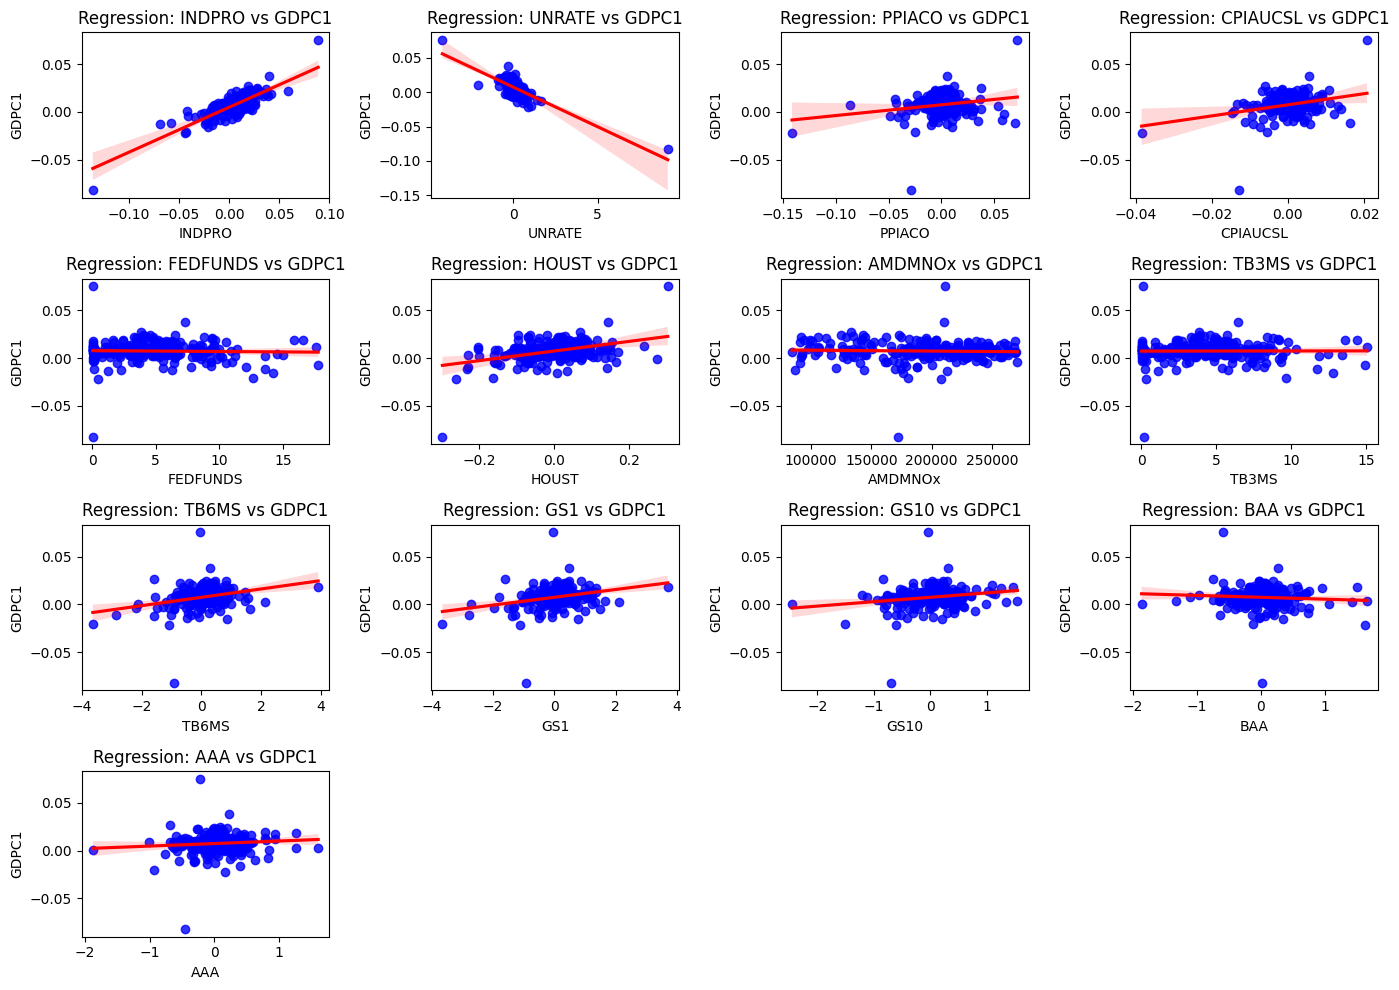

In [191]:
# Data Visualisation of X Variables against Y Variable

# List of variables to plot against GDPC1
variables = ['INDPRO', 'UNRATE', 'PPIACO', 'CPIAUCSL', 'FEDFUNDS', 'HOUST', 'AMDMNOx', 'TB3MS', 'TB6MS', 'GS1', 'GS10', 'BAA', 'AAA']

# Plotting
plt.figure(figsize=(14, 10))

# Loop through each variable
for i, var in enumerate(variables, 1):
    # Add subplot
    plt.subplot(4, 4, i)
    
    # Prepare data for regression (drop NaN values)
    data_for_regression = df1_stationarised[[var, 'GDPC1']].dropna()
    
    # Independent variable (X) and dependent variable (y)
    X = sm.add_constant(data_for_regression[var])  # Adding a constant for intercept
    y = data_for_regression['GDPC1']
    
    # Fit the regression model
    model = sm.OLS(y, X).fit()
    
    # Plot the scatter plot and the regression line
    sns.regplot(x=var, y='GDPC1', data=data_for_regression, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
    
    # Set titles and labels
    plt.title(f'Regression: {var} vs GDPC1')
    plt.xlabel(var)
    plt.ylabel('GDPC1')

# Adjust layout
plt.tight_layout()
plt.show()

In [192]:
# Tabulate the Descriptive Statistics

# Assuming df1_stationarised is your DataFrame
summary = df1_stationarised.describe()

# Convert the DataFrame summary to a nice table format
table = tabulate(summary, headers='keys', tablefmt='pipe', numalign="center", floatfmt=".4f")

# Print the table for easy copy-pasting
print(table)


|       |  GDPC1   |  INDPRO  |  UNRATE  |  PPIACO  |  CPIAUCSL  |  FEDFUNDS  |  HOUST   |   AMDMNOx   |  TB3MS   |  TB6MS   |   GS1    |   GS10   |   BAA    |   AAA    |
|:------|:--------:|:--------:|:--------:|:--------:|:----------:|:----------:|:--------:|:-----------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|
| count | 261.0000 | 261.0000 | 261.0000 | 261.0000 |  261.0000  |  261.0000  | 261.0000 |  261.0000   | 261.0000 | 261.0000 | 261.0000 | 261.0000 | 261.0000 | 261.0000 |
| mean  |  0.0074  |  0.0057  | -0.0034  | -0.0000  |   0.0000   |   4.7922   | -0.0005  | 195433.3369 |  4.3742  |  0.0052  |  0.0021  | -0.0012  |  0.0026  |  0.0021  |
| std   |  0.0106  |  0.0186  |  0.7169  |  0.0196  |   0.0053   |   3.6196   |  0.0855  | 46481.6901  |  3.1269  |  0.6748  |  0.7050  |  0.4611  |  0.4035  |  0.3695  |
| min   | -0.0824  | -0.1361  | -4.2000  | -0.1412  |  -0.0385   |   0.0600   | -0.2991  | 84042.3884  |  0.0133  | -3.6333  | -3.6500  | -2.4500

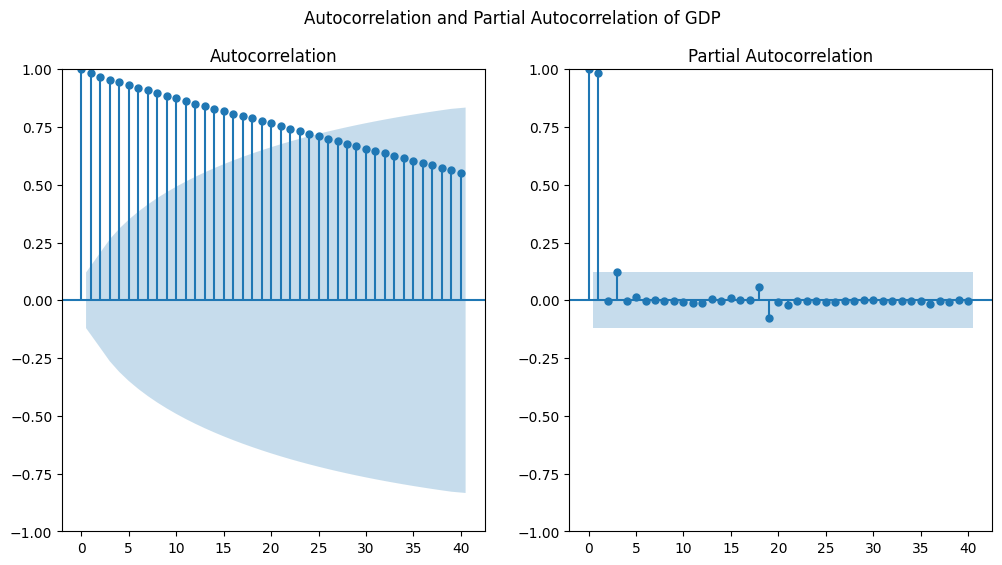

In [193]:
# Autocorrelation and Partial Autocorrelation for GDP
plt.figure(figsize=(12, 6))
plot_acf(df1['GDPC1'], lags=40, ax=plt.subplot(121))
plot_pacf(df1['GDPC1'], lags=40, ax=plt.subplot(122))
plt.suptitle('Autocorrelation and Partial Autocorrelation of GDP')
plt.show()

/var/folders/9s/g3dm127d28j72x1bc2hpx0980000gp/T/ipykernel_739/1134338372.py:66: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_index = pd.date_range(


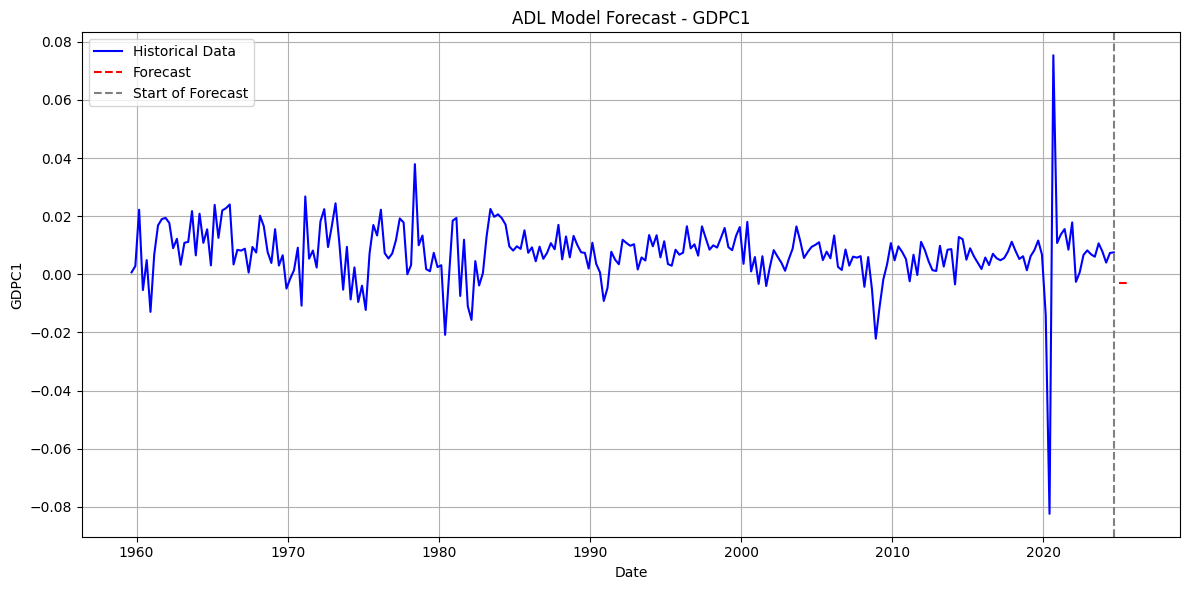


Model Summary:
                            OLS Regression Results                            
Dep. Variable:                  GDPC1   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     61.27
Date:                Wed, 12 Feb 2025   Prob (F-statistic):           2.10e-69
Time:                        00:16:34   Log-Likelihood:                 1000.2
No. Observations:                 260   AIC:                            -1972.
Df Residuals:                     246   BIC:                            -1922.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0069      0.002    

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels import api as sm

def load_and_prepare_data(quarterly_file, monthly_file, selected_columns):
    """Load and prepare the data from CSV files."""
    df1 = pd.read_csv(quarterly_file)
    df2 = pd.read_csv(monthly_file)  # Note: df2 isn't used in current implementation
    
    df1_filtered = df1[selected_columns]
    header_row = df1_filtered.iloc[0]
    transform_row = df1_filtered.iloc[1]
    data = df1_filtered.iloc[2:]
    
    return df1_filtered, header_row, transform_row, data

def transform_column(series, transform_type):
    """Apply the specified transformation to a data series."""
    transformations = {
        1: lambda x: x,  # No transformation
        2: lambda x: x.diff(),  # First difference
        3: lambda x: x.diff().diff(),  # Second difference
        4: lambda x: np.log(x),  # Log
        5: lambda x: np.log(x).diff(),  # Log difference
        6: lambda x: np.log(x).diff().diff(),  # Second log difference
        7: lambda x: (x / x.shift(1) - 1).diff()  # Growth rate difference
    }
    
    return transformations.get(transform_type, lambda x: x)(series)

def prepare_stationarised_data(data, header_row, transform_row):
    """Transform data to achieve stationarity."""
    stationarised_data = data.copy()
    
    for col in data.columns:
        if header_row[col] != 1:
            transform_type = transform_row[col]
            stationarised_data[col] = transform_column(data[col], transform_type)
    
    return stationarised_data.dropna()

def create_adl_model(df, dependent_var, independent_vars, max_lag_y=1, max_lag_x=1):
    """Create and fit the ADL model."""
    # Prepare dependent and independent variables
    y = df[dependent_var]
    X = df[independent_vars]
    
    # Create lags
    y_lagged = y.shift(max_lag_y)
    X_lagged = X.shift(max_lag_x)
    
    # Combine lagged variables
    df_lagged = pd.concat([y_lagged, X_lagged], axis=1).dropna()
    
    # Add constant and fit model
    X_lagged_with_const = sm.add_constant(df_lagged.iloc[:, 1:])
    model = sm.OLS(df_lagged.iloc[:, 0], X_lagged_with_const)
    results = model.fit()
    
    return results, df_lagged

def generate_forecast(model_results, df, dependent_var, independent_vars, forecast_periods=4):
    """Generate forecasts using the fitted model."""
    # Create future dates
    future_index = pd.date_range(
        start=df.index[-1] + pd.DateOffset(months=3),
        periods=forecast_periods,
        freq='Q'
    )
    
    # Create future independent variables (using last known values)
    X = df[independent_vars]
    X_future = pd.DataFrame(
        np.tile(X.iloc[-1].values, (forecast_periods, 1)),
        columns=X.columns,
        index=future_index
    )
    
    # Create lagged variables for forecasting
    y_future_lagged = pd.Series(
        [df[dependent_var].iloc[-1]] * forecast_periods,
        index=future_index
    )
    
    # Prepare future data for forecasting
    future_lagged_data = pd.concat([y_future_lagged, X_future], axis=1)
    X_future_with_const = sm.add_constant(future_lagged_data)
    
    # Generate forecasts
    forecast_values = model_results.predict(X_future_with_const)
    return pd.Series(forecast_values, index=future_index)

def plot_results(historical_data, forecast_data, dependent_var):
    """Plot historical data and forecasts."""
    plt.figure(figsize=(12, 6))
    plt.plot(historical_data[dependent_var], label="Historical Data", color="blue")
    plt.plot(forecast_data, label="Forecast", color="red", linestyle="--")
    plt.axvline(x=historical_data.index[-1], color='gray', linestyle='--', label="Start of Forecast")
    plt.legend()
    plt.title(f"ADL Model Forecast - {dependent_var}")
    plt.xlabel("Date")
    plt.ylabel(dependent_var)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def main():
    # Define columns
    selected_columns = [
        "sasdate", "GDPC1", "INDPRO", "UNRATE", "PPIACO", "CPIAUCSL",
        "FEDFUNDS", "HOUST", "AMDMNOx", "TB3MS", "TB6MS", "GS1", "GS10",
        "BAA", "AAA"
    ]
    
    # Load and prepare data
    df1_filtered, header_row, transform_row, data = load_and_prepare_data(
        "Quarterly Data.csv",
        "Monthly Data.csv",
        selected_columns
    )
    
    # Prepare stationarised data
    stationarised_data = prepare_stationarised_data(data, header_row, transform_row)
    
    # Convert dates and set index
    stationarised_data['sasdate'] = pd.to_datetime(stationarised_data['sasdate'])
    stationarised_data.set_index('sasdate', inplace=True)
    
    # Define dependent and independent variables
    dependent_var = 'GDPC1'
    independent_vars = [col for col in selected_columns if col not in ['sasdate', dependent_var]]
    
    # Create and fit model
    model_results, df_lagged = create_adl_model(
        stationarised_data,
        dependent_var,
        independent_vars
    )
    
    # Generate forecast
    forecast = generate_forecast(
        model_results,
        stationarised_data,
        dependent_var,
        independent_vars
    )
    
    # Plot results
    plot_results(stationarised_data, forecast, dependent_var)
    
    # Print model summary and forecasts
    print("\nModel Summary:")
    print(model_results.summary())
    print("\nForecasted Values:")
    print(forecast)

if __name__ == "__main__":
    main()

#### Remember to rename your file name to **NUS_DSESC_DATABUSTERS_XX.ipynb** and ensure that it can run successfully. Good luck and have fun!